In [138]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

In [139]:
data=pd.read_csv('/kaggle/input/competitions/digit-recognizer/train.csv')

In [140]:
data.head()

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [141]:
data=np.array(data)
m,n=data.shape
np.random.shuffle(data)

# validation set
data_dev=data[0:1000].T
Y_dev=data_dev[0]
X_dev=data_dev[1:n]
X_dev=X_dev/255

# training set
data_train=data[1000:m].T
Y_train=data_train[0]
X_train=data_train[1:n]
X_train=X_train/255



In [142]:
Y_train


array([5, 7, 1, ..., 4, 7, 2])

In [143]:
X_train[:,0].shape

(784,)

In [144]:
def init_params():
    w1= np.random.rand(10,784)-0.5
    b1= np.random.rand(10,1)-0.5
    w2= np.random.rand(10,10)-0.5
    b2= np.random.rand(10,1)-0.5
    return w1,b1,w2,b2
def ReLu(Z):
    return np.maximum(Z,0)

def softmax(Z):
    A=np.exp(Z)/sum(np.exp(Z))
    return A

def forward_prop(w1,b1,w2,b2,X):
    Z1=w1.dot(X)+b1
    A1=ReLu(Z1)
    Z2=w2.dot(A1)+b2
    A2=softmax(Z2)
    return Z1,A1,Z2,A2
def ReLu_deriv(Z):
    return Z>0

def one_hot(Y):
    one_hot_Y= np.zeros((Y.size,Y.max()+1))
    one_hot_Y[np.arange(Y.size),Y]=1
    one_hot_Y=one_hot_Y.T
    return one_hot_Y
    
    
def backward_prop(Z1,A1,Z2,A2,w1,w2,X,Y):
    one_hot_Y= one_hot(Y)
    dz2=A2-one_hot_Y
    dw2=1/m*dz2.dot(A1.T)
    db2=1/m* np.sum(dz2)
    dz1=w2.T.dot(dz2)*ReLu_deriv(Z1)
    dw1=1/m*dz1.dot(X.T)
    db1=1/m*np.sum(dz1)
    return dw1,db1,dw2,db2

def update_params(w1,b1,w2,b2,dw1,db1,dw2,db2,alpha):
    w1=w1-alpha*dw1
    b1=b1-alpha*db1
    w2=w2-alpha*dw2
    b2=b2-alpha*db2
    return w1,b1,w2,b2

    
    

In [145]:
def get_predictions(A2):
    return np.argmax(A2,0)

def get_accuracy(predictions,Y):
    print(predictions,Y)
    return np.sum(predictions ==Y)/Y.size

def gradient_descent(X,Y,alpha,iterations):
    w1,b1,w2,b2=init_params()
    for i in range(iterations):
        Z1,A1,Z2,A2=forward_prop(w1,b1,w2,b2,X)
        dw1,db1,dw2,db2= backward_prop(Z1,A1,Z2,A2,w1,w2,X,Y)
        w1,b1,w2,b2=update_params(w1,b1,w2,b2,dw1,db1,dw2,db2,alpha)
        if i % 10==0:
            print("Iteraion: ",i)
            predictions=get_predictions(A2)
            print(get_accuracy(predictions,Y))
    return w1,b1,w2,b2

In [146]:
w1, b1, w2, b2 = gradient_descent(X_train, Y_train, 0.10, 500)

Iteraion:  0
[6 2 2 ... 2 2 4] [5 7 1 ... 4 7 2]
0.09721951219512195
Iteraion:  10
[6 2 1 ... 1 9 0] [5 7 1 ... 4 7 2]
0.16463414634146342
Iteraion:  20
[6 2 1 ... 1 9 0] [5 7 1 ... 4 7 2]
0.26526829268292684
Iteraion:  30
[6 2 1 ... 9 9 0] [5 7 1 ... 4 7 2]
0.35965853658536584
Iteraion:  40
[6 9 1 ... 4 9 0] [5 7 1 ... 4 7 2]
0.4387560975609756
Iteraion:  50
[5 9 1 ... 4 9 0] [5 7 1 ... 4 7 2]
0.500390243902439
Iteraion:  60
[5 9 1 ... 4 7 0] [5 7 1 ... 4 7 2]
0.5531463414634147
Iteraion:  70
[5 9 1 ... 4 7 0] [5 7 1 ... 4 7 2]
0.6048536585365853
Iteraion:  80
[5 7 1 ... 4 7 0] [5 7 1 ... 4 7 2]
0.6450975609756098
Iteraion:  90
[5 7 1 ... 4 7 2] [5 7 1 ... 4 7 2]
0.6733170731707318
Iteraion:  100
[5 7 1 ... 4 7 2] [5 7 1 ... 4 7 2]
0.6936341463414634
Iteraion:  110
[5 7 1 ... 4 7 2] [5 7 1 ... 4 7 2]
0.7108048780487805
Iteraion:  120
[5 7 1 ... 4 7 2] [5 7 1 ... 4 7 2]
0.7255365853658536
Iteraion:  130
[5 7 1 ... 4 7 2] [5 7 1 ... 4 7 2]
0.7367317073170732
Iteraion:  140
[5 7 1 ... 4 

Prediction:  [5]
Label:  5


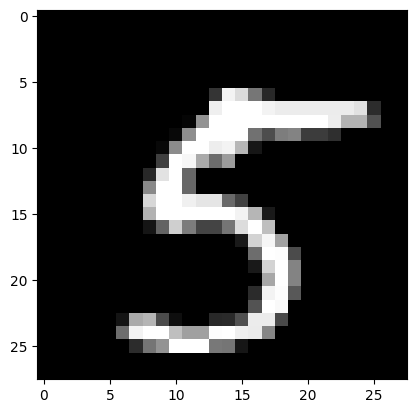

In [147]:

def make_predictions(X, w1, b1, w2, b2):
    # Fixed: Changed w1, w2 to capital W1, W2 to match forward_prop
    _, _, _, A2 = forward_prop(w1, b1, w2, b2, X)
    predictions = get_predictions(A2)
    return predictions

def test_prediction(index, w1, b1, w2, b2):
    # Extracts a single column (one image) and preserves its 2D array structure
    current_image = X_train[:, index, None]
    
    # Fixed: Passing capital W1 and W2 into make_predictions
    prediction = make_predictions(current_image, w1, b1, w2, b2)
    label = Y_train[index]
    
    print("Prediction: ", prediction)
    print("Label: ", label)
    
    # Reshapes the flat 784 pixels back into a 28x28 visual grid
    current_image = current_image.reshape((28, 28)) * 255
    plt.gray()
    plt.imshow(current_image, interpolation='nearest')
    plt.show()

# --- CALL THE FUNCTION HERE TO RUN IT ---
# This will test your trained model on the very first image (index 0) of your dataset
test_prediction(0, w1, b1, w2, b2)

Prediction:  [1]
Label:  1


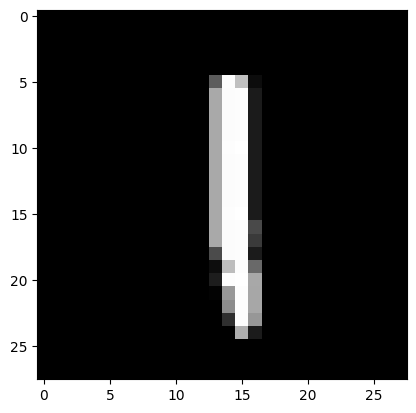

In [150]:
test_prediction(106, w1, b1, w2, b2)
